In [1]:
#### install and load packages needed for graphing #############################

# install.packages("tidyverse")
# install.packages("cowplot")

library(tidyverse)
library(cowplot)

stage_colors <- c(immature = "#93C572", mature = "#3F7A43")
outline      <- "grey25"

theme_set(theme_cowplot(font_size = 12))
options(repr.plot.width = 8, repr.plot.height = 4.5)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




In [2]:
#### read in data ##############################################################

source("R/reshape_trichomes.R")

trichomes <- reshape_trichomes("trichome measurements.xlsx")
write_csv(trichomes, "data/trichome_measurements_tidy.csv", na = "")

trichomes$Stage <- factor(trichomes$Stage, levels = c("immature", "mature"))

trichomes

Stage,Tissue,Face,Trichome,TrichomeID,Branch,Perimeter,Length,Note
<fct>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>
mature,throat,outside,circle,mthf circle trichome,NA,226.193,NA,NA
mature,stomach,outside,branched,mstf trichome 3,NA,NA,104.974,NA
mature,stomach,outside,branched,mstf_trichome_2_branches,1,NA,45.557,NA
mature,stomach,outside,branched,mstf_trichome_2_branches,2,NA,45.382,NA
mature,stomach,outside,branched,mstf_trichome_2_branches,3,NA,32.345,NA
mature,stomach,outside,branched,mstf_trichome_2_branches,4,NA,47.078,NA
mature,stomach,outside,branched,mstf_trichome_2_branches,5,NA,78.481,NA
mature,stomach,outside,branched,mstf_trichome_1_branches,1,NA,42.228,NA
mature,stomach,outside,branched,mstf_trichome_1_branches,2,NA,19.747,NA


In [3]:
#### create objects that filter out specific measurements ######################

trichomes %>%
  filter(Trichome == "circle") -> circles

trichomes %>%
  filter(Trichome == "branched") -> brancheds

# istf_trichome1 is a long unbranched hair measured at 350x - a different
# morphotype, so it is not comparable with the mature branch lengths
brancheds %>%
  filter(TrichomeID != "istf_trichome1") -> comparable

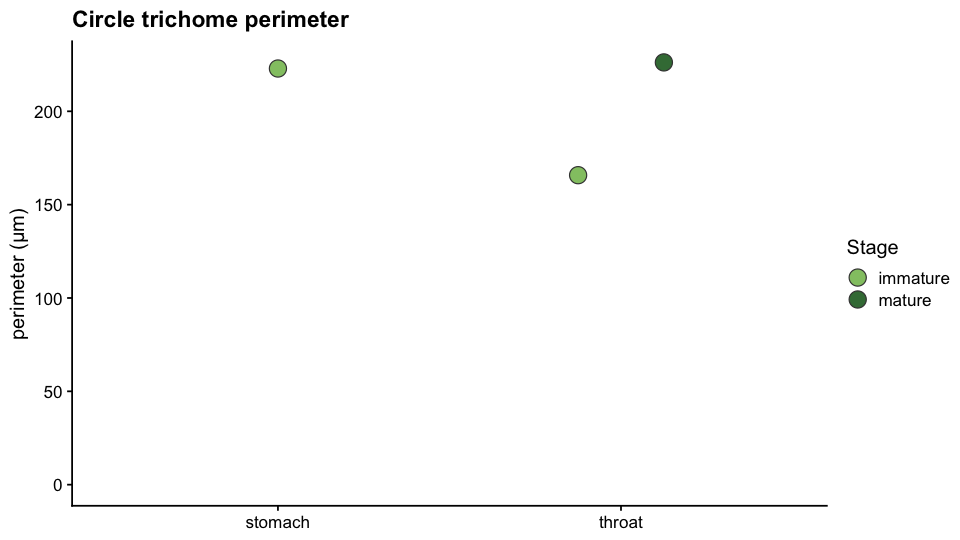

In [4]:
#### plot circle trichomes #####################################################

# n = 1 in every group, so show the measurements themselves, not a mean

plot1 <- ggplot(circles, aes(x = Tissue, y = Perimeter, fill = Stage)) +
  geom_point(shape = 21, size = 4.5, stroke = 0.5, colour = outline,
             position = position_dodge(width = 0.5)) +
  scale_fill_manual(values = stage_colors) +
  scale_y_continuous(limits = c(0, NA)) +
  labs(title = "Circle trichome perimeter", x = NULL, y = "perimeter (µm)")

plot1
ggsave("output/trichome_circle_perimeter.png", plot1, width = 7, height = 4.5, dpi = 300)

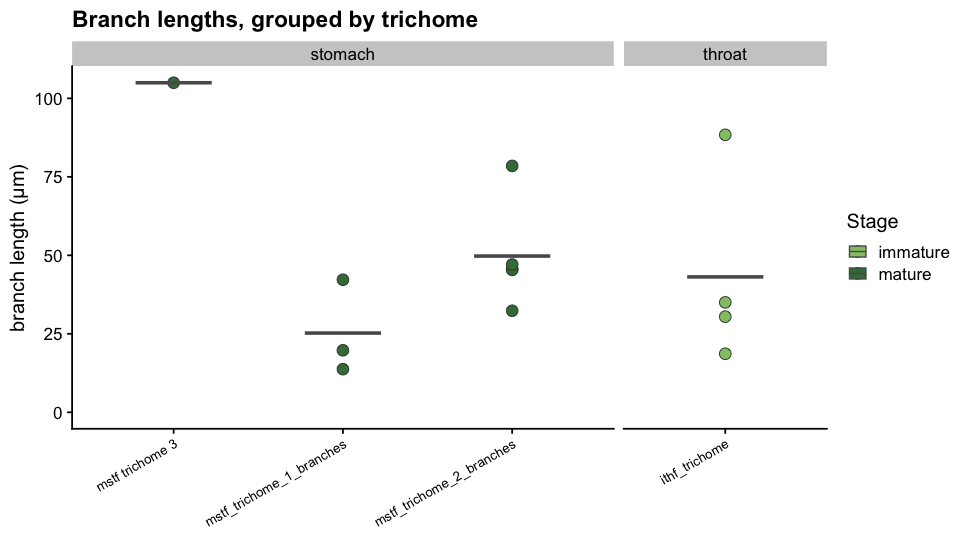

In [5]:
#### plot branched trichomes ###################################################

plot2 <- ggplot(comparable, aes(x = TrichomeID, y = Length, fill = Stage)) +
  geom_point(shape = 21, size = 3, stroke = 0.4, colour = outline) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.45,
               linewidth = 0.4, colour = "grey35") +
  scale_fill_manual(values = stage_colors) +
  scale_y_continuous(limits = c(0, NA)) +
  facet_grid(~ Tissue, scales = "free_x", space = "free_x") +
  labs(title = "Branch lengths, grouped by trichome",
       x = NULL, y = "branch length (µm)") +
  theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 8))

plot2
ggsave("output/trichome_branch_lengths.png", plot2, width = 8, height = 4.5, dpi = 300)

In [6]:
#### how many trichomes are behind each group ##################################

# branches are not replicates - 9 branch rows come from only 3 trichomes

brancheds %>%
  group_by(Stage, Tissue) %>%
  summarise(trichomes = n_distinct(TrichomeID), branch_rows = n(), .groups = "drop")

Stage,Tissue,trichomes,branch_rows
<fct>,<chr>,<int>,<int>
immature,stomach,1,1
immature,throat,1,4
mature,stomach,3,9
